In [174]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [175]:
processed_path = r"C:\Users\Mahakaal\Documents\HOUSE-PRICE-PREDICTION\data\proccessed\cleaned_bengaluru_house_data.csv"
df = pd.read_csv(processed_path, dtype={'area_type': 'category'})

In [176]:
df["area_type"].value_counts()

area_type
Super built-up  Area    8436
Built-up  Area          2246
Plot  Area              1273
Carpet  Area              79
Name: count, dtype: int64

In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12034 entries, 0 to 12033
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   area_type      12034 non-null  category
 1   location       12034 non-null  object  
 2   total_sqft     12034 non-null  float64 
 3   bath           12034 non-null  int64   
 4   balcony        12034 non-null  int64   
 5   price          12034 non-null  float64 
 6   ready_to_move  12034 non-null  int64   
 7   bedrooms       12034 non-null  int64   
dtypes: category(1), float64(2), int64(4), object(1)
memory usage: 670.2+ KB


In [178]:
location_stats = df["location"].value_counts()
rare_locations = set(location_stats[location_stats <= 10].index)
df["location"] = df["location"].apply(
    lambda x: "other" if x in rare_locations else x
)

df["price_per_sqft"] = df["price"] / df["total_sqft"]
df['bath_to_bhk_ratio'] = df['bath'] / df['bedrooms']


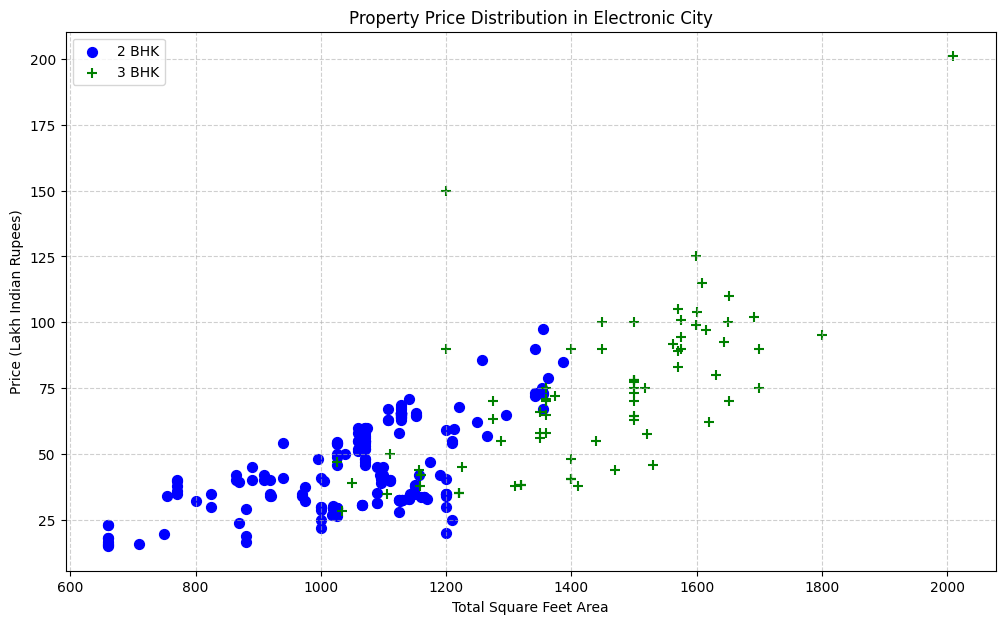

In [179]:
def plot_scatter_chart(df, location):
    bhk2 = df[(df['location'] == location) & (df['bedrooms'] == 2)]
    bhk3 = df[(df['location'] == location) & (df['bedrooms'] == 3)]
    
    plt.figure(figsize=(12, 7))
    
    plt.scatter(bhk2['total_sqft'], bhk2['price'] / 100000, color='blue', label='2 BHK', s=50)
    plt.scatter(bhk3['total_sqft'], bhk3['price'] / 100000, color='green', marker='+', label='3 BHK', s=50)
    
    plt.xlabel("Total Square Feet Area")
    plt.ylabel("Price (Lakh Indian Rupees)")
    plt.title(f"Property Price Distribution in {location.title()}")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

plot_scatter_chart(df, "electronic city")

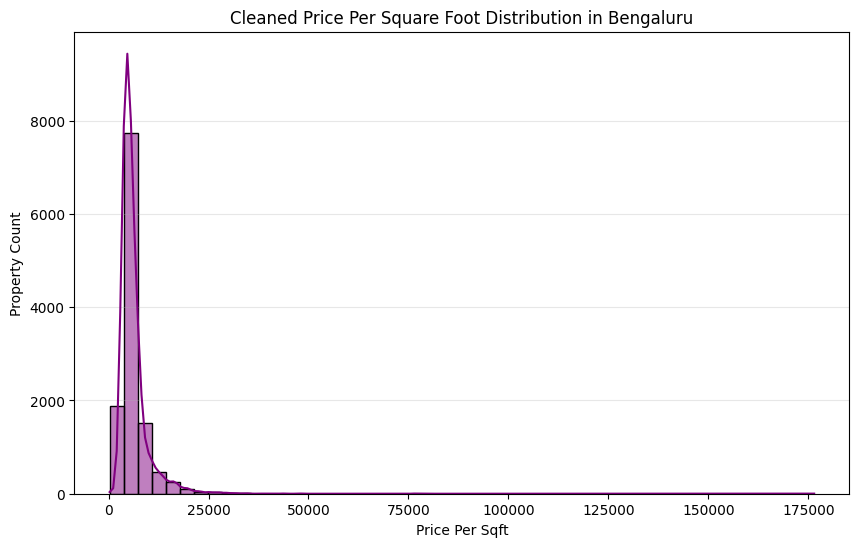

In [180]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price_per_sqft'], kde=True, bins=50, color='purple')
plt.title("Cleaned Price Per Square Foot Distribution in Bengaluru")
plt.xlabel("Price Per Sqft")
plt.ylabel("Property Count")
plt.grid(axis='y', alpha=0.3)
plt.show()

In [181]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby("location"):
        m = np.mean(subdf["price_per_sqft"])
        st = np.std(subdf["price_per_sqft"])
        reduced_df = subdf[
            (subdf["price_per_sqft"] > (m - st))
            & (subdf["price_per_sqft"] <= (m + st))
        ]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out


df = remove_pps_outliers(df)
df = df.reset_index(drop=True)
print(f"Dataset shape after pricing outlier removal: {df.shape}")

Dataset shape after pricing outlier removal: (9893, 10)


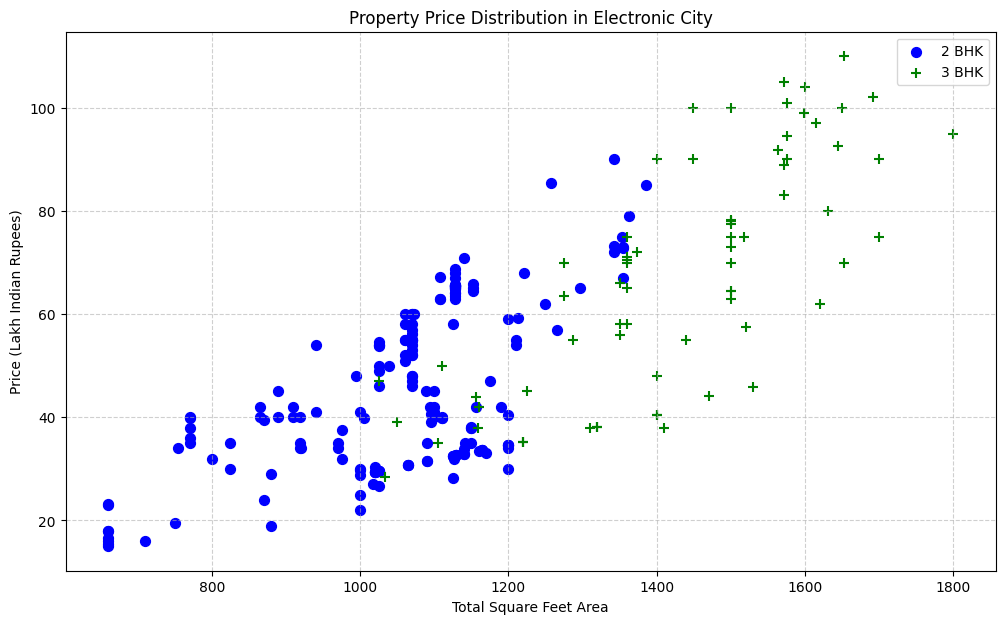

In [182]:
def plot_scatter_chart(df, location):
    bhk2 = df[(df['location'] == location) & (df['bedrooms'] == 2)]
    bhk3 = df[(df['location'] == location) & (df['bedrooms'] == 3)]
    
    plt.figure(figsize=(12, 7))
    
    plt.scatter(bhk2['total_sqft'], bhk2['price'] / 100000, color='blue', label='2 BHK', s=50)
    plt.scatter(bhk3['total_sqft'], bhk3['price'] / 100000, color='green', marker='+', label='3 BHK', s=50)
    
    plt.xlabel("Total Square Feet Area")
    plt.ylabel("Price (Lakh Indian Rupees)")
    plt.title(f"Property Price Distribution in {location.title()}")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

plot_scatter_chart(df, "electronic city")

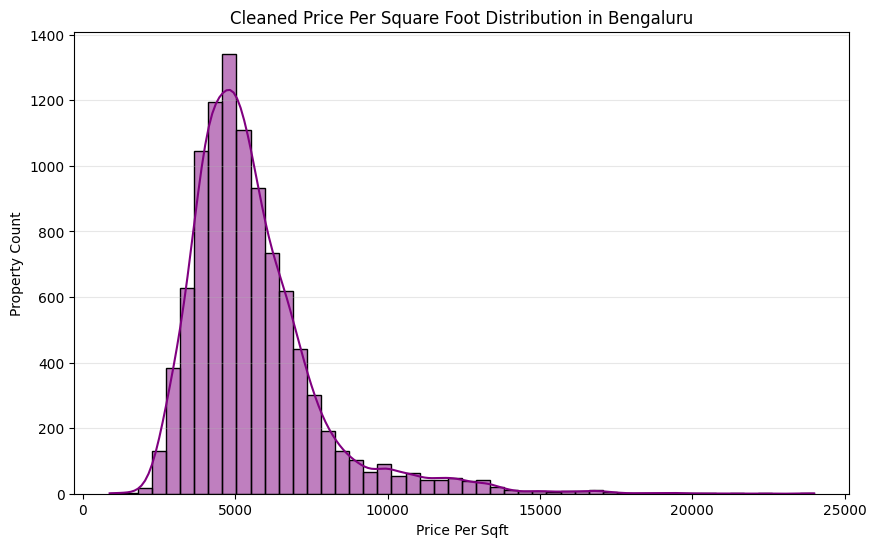

In [183]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price_per_sqft'], kde=True, bins=50, color='purple')
plt.title("Cleaned Price Per Square Foot Distribution in Bengaluru")
plt.xlabel("Price Per Sqft")
plt.ylabel("Property Count")
plt.grid(axis='y', alpha=0.3)
plt.show()

In [184]:
def remove_bhk_outliers(df):
    exclude_rows = np.array([])
    for location, location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bedrooms'):
            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df['price_per_sqft']),
                'std': np.std(bhk_df['price_per_sqft']),
                'count': bhk_df.shape[0]
            }
        for bhk, bhk_df in location_df.groupby('bedrooms'):
            stats = bhk_stats.get(bhk-1)
            if stats and stats['count'] > 5:
                corrupted_rows = bhk_df[bhk_df['price_per_sqft'] < stats['mean']].index
                exclude_rows = np.append(exclude_rows, corrupted_rows)
                
    return df.drop(exclude_rows, axis='index')

df = remove_bhk_outliers(df)
df = df.reset_index(drop=True)
print(f"Shape after cleaning BHK price anomalies: {df.shape}")

Shape after cleaning BHK price anomalies: (6973, 10)


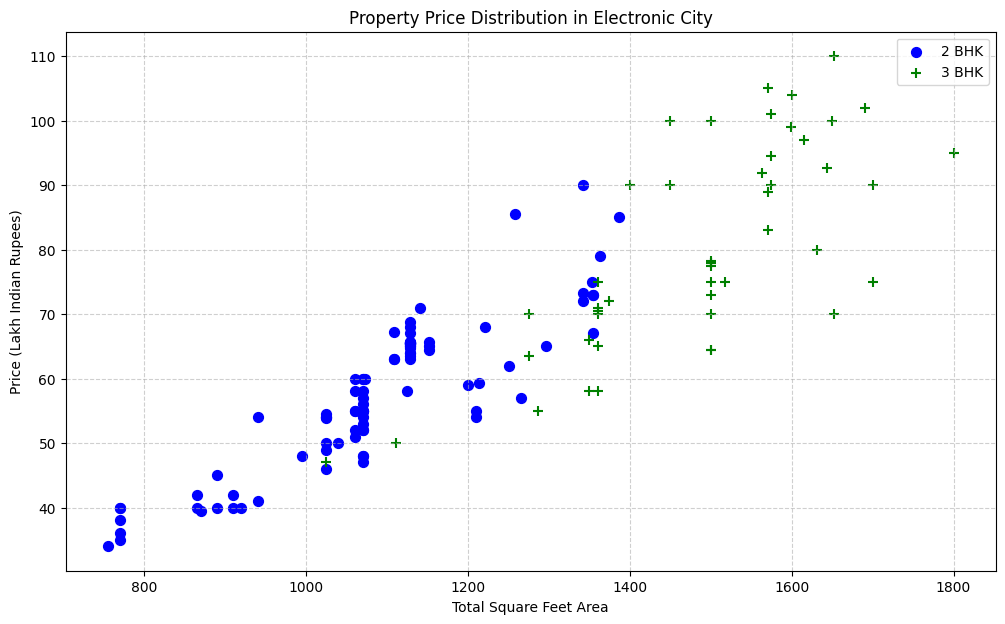

In [185]:
def plot_scatter_chart(df, location):
    bhk2 = df[(df['location'] == location) & (df['bedrooms'] == 2)]
    bhk3 = df[(df['location'] == location) & (df['bedrooms'] == 3)]
    
    plt.figure(figsize=(12, 7))
    
    plt.scatter(bhk2['total_sqft'], bhk2['price'] / 100000, color='blue', label='2 BHK', s=50)
    plt.scatter(bhk3['total_sqft'], bhk3['price'] / 100000, color='green', marker='+', label='3 BHK', s=50)
    
    plt.xlabel("Total Square Feet Area")
    plt.ylabel("Price (Lakh Indian Rupees)")
    plt.title(f"Property Price Distribution in {location.title()}")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

plot_scatter_chart(df, "electronic city")

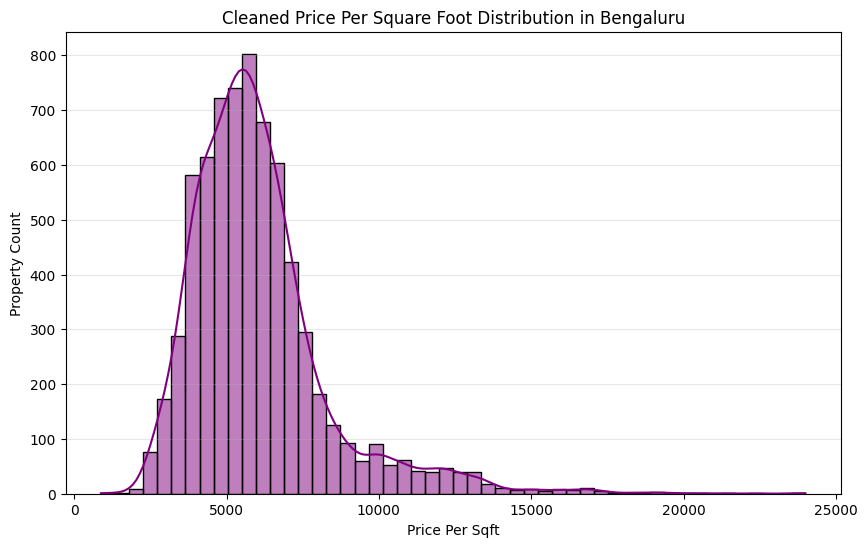

In [186]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price_per_sqft'], kde=True, bins=50, color='purple')
plt.title("Cleaned Price Per Square Foot Distribution in Bengaluru")
plt.xlabel("Price Per Sqft")
plt.ylabel("Property Count")
plt.grid(axis='y', alpha=0.3)
plt.show()

In [187]:
location_dummy=pd.get_dummies(df['location'], drop_first=True, dtype='int64')
area_type_dummy=pd.get_dummies(df['area_type'], drop_first=True, dtype='int64')

In [188]:
upper_sqft_limit = df['price_per_sqft'].quantile(0.98)
lower_sqft_limit = df['price_per_sqft'].quantile(0.01)

df_cleaned = df[
    (df['price_per_sqft'] <= upper_sqft_limit) & 
    (df['price_per_sqft'] >= lower_sqft_limit)
]

In [189]:
df_vectorized = pd.concat([df_cleaned, location_dummy, area_type_dummy], axis=1)
df_vectorized = df_vectorized.drop(columns=['location', 'area_type', 'price_per_sqft', 'bath_to_bhk_ratio'])
df_vectorized=df_vectorized.dropna()
df_vectorized = df_vectorized.reset_index(drop=True)

In [190]:
df_vectorized.columns.tolist()

['total_sqft',
 'bath',
 'balcony',
 'price',
 'ready_to_move',
 'bedrooms',
 '2nd phase judicial layout',
 '5th phase jp nagar',
 '6th phase jp nagar',
 '7th phase jp nagar',
 '8th phase jp nagar',
 '9th phase jp nagar',
 'abbigere',
 'aecs layout',
 'akshaya nagar',
 'ambalipura',
 'ambedkar nagar',
 'amruthahalli',
 'anandapura',
 'ananth nagar',
 'anekal',
 'anjanapura',
 'ardendale',
 'arekere',
 'attibele',
 'babusapalaya',
 'badavala nagar',
 'balagere',
 'banashankari',
 'banashankari stage ii',
 'banashankari stage iii',
 'banashankari stage v',
 'banashankari stage vi',
 'banaswadi',
 'bannerghatta',
 'bannerghatta road',
 'basavangudi',
 'basaveshwara nagar',
 'battarahalli',
 'begur',
 'begur road',
 'bellandur',
 'beml layout',
 'benson town',
 'bharathi nagar',
 'bhoganhalli',
 'billekahalli',
 'binny pete',
 'bisuvanahalli',
 'bommanahalli',
 'bommasandra',
 'bommasandra industrial area',
 'bommenahalli',
 'brookefield',
 'btm 2nd stage',
 'btm layout',
 'budigere',
 'ch

In [191]:
vectorized_output_path = r"C:\Users\Mahakaal\Documents\HOUSE-PRICE-PREDICTION\data\proccessed\bengaluru_vectorized_final.csv"
df_vectorized.to_csv(vectorized_output_path, index=False)